# Bathymetry Tutorial

This tutorial covers the **XBeachBathy** class in `rompy-xbeach`, which handles
bathymetry interpolation and file generation for XBeach simulations.

## What You'll Learn

1. Loading bathymetry data from various sources
2. Defining a grid aligned with the bathymetry
3. Interpolating bathymetry onto the XBeach grid
4. Extending the domain offshore and laterally
5. Visualising and validating the interpolated bathymetry

## Prerequisites

- Familiarity with the `RegularGrid` class (see **Grid Tutorial**)
- Understanding of coordinate reference systems
- Basic knowledge of data sources (see **Source Tutorial** for details on
  `SourceGeotiff` and other source types)

In [1]:
from pathlib import Path
import xarray as xr
import rioxarray
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

from rompy_xbeach.grid import GeoPoint, RegularGrid
from rompy_xbeach.source import SourceGeotiff
from rompy_xbeach.data import XBeachBathy, SeawardExtensionLinear
from rompy_xbeach.interpolate import RegularGridInterpolator

import warnings
warnings.filterwarnings("ignore")

---
## 1. Loading Source Bathymetry

First, let's load and inspect the source bathymetry data. This example uses
a GeoTIFF file, but rompy-xbeach supports various data sources.

In [2]:
from pathlib import Path

# Change the data directory to the location in your computer where rompy-xbeach is cloned into
DATADIR = Path("../../../../rompy-xbeach/tests/data")

In [3]:
# Load bathymetry using rioxarray for inspection
bathy = rioxarray.open_rasterio(DATADIR / "bathy.tif")
bathy = bathy.isel(band=0, drop=True)

print(f"Shape: {bathy.shape}")
print(f"CRS: {bathy.rio.crs}")
print(f"Bounds: x=[{float(bathy.x.min()):.4f}, {float(bathy.x.max()):.4f}], "
      f"y=[{float(bathy.y.min()):.4f}, {float(bathy.y.max()):.4f}]")

Shape: (180, 176)
CRS: EPSG:4326
Bounds: x=[115.5915, 115.6289], y=[-32.6483, -32.6101]


Text(0.5, 1.0, 'Source Bathymetry (WGS84)')

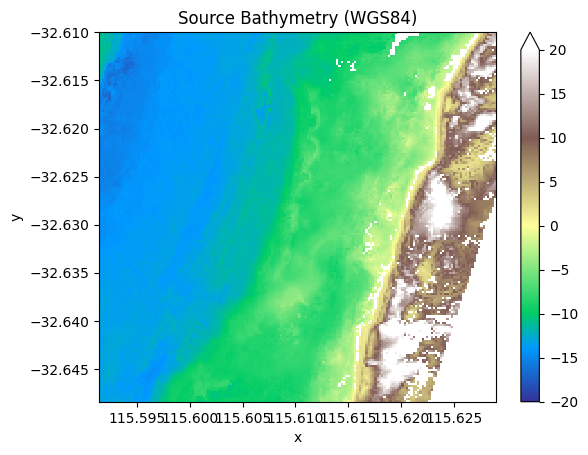

In [4]:
# Visualise the source bathymetry
bathy.plot(cmap="terrain", vmin=-20, vmax=20)
plt.title("Source Bathymetry (WGS84)")

---
## 2. Defining the XBeach Grid

The grid must be oriented so that:
- The **offshore boundary** (front) faces the open ocean
- The **origin** is at the onshore corner
- The **x-axis** points offshore (cross-shore direction)

The `plot()` method highlights the origin (red dot) and offshore boundary
(red line) to help verify correct orientation.

In [5]:
grid = RegularGrid(
    ori=GeoPoint(
        x=115.594239,
        y=-32.641104,
        crs=bathy.rio.crs,  # Origin in same CRS as bathymetry
    ),
    alfa=347,    # Rotation angle (degrees from East)
    dx=10,       # Cross-shore resolution (m)
    dy=15,       # Alongshore resolution (m)
    nx=230,      # Cross-shore cells
    ny=220,      # Alongshore cells
    crs="28350", # Grid CRS (MGA Zone 50)
)

### Visualising Grid on Bathymetry

Overlay the grid on the bathymetry to verify alignment:

Text(0.5, 1.0, 'Grid aligned with bathymetry\n(Red dot = origin, Red line = offshore)')

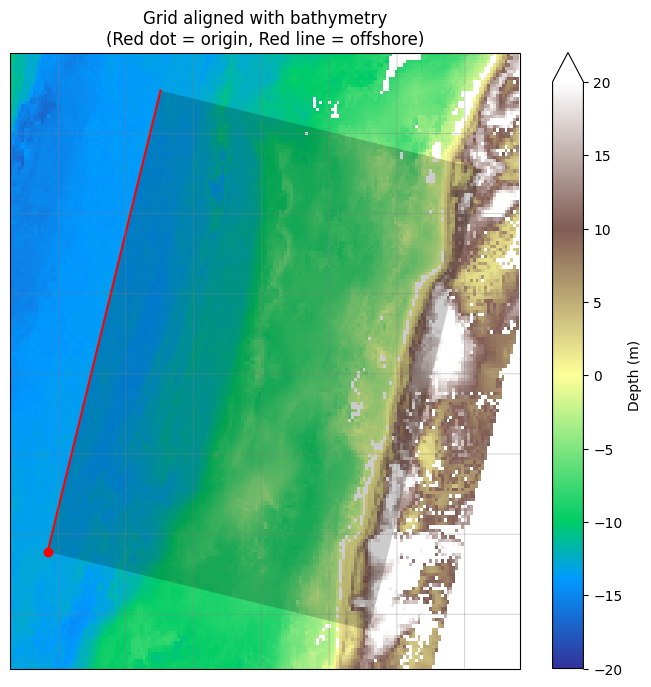

In [6]:
fig, ax = plt.subplots(subplot_kw={"projection": grid.projection}, figsize=(8.5, 8))

# Plot bathymetry
bathy.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="terrain",
    vmin=-20, vmax=20,
    cbar_kwargs=dict(label="Depth (m)"),
)

# Overlay grid with origin and offshore boundary highlighted
grid.plot(
    ax=ax,
    buffer=250,
    grid_kwargs=dict(facecolor="k", alpha=0.2),
    show_offshore=True,
    show_origin=True,
)

ax.set_title("Grid aligned with bathymetry\n(Red dot = origin, Red line = offshore)")

### Common Mistake: Incorrect Grid Orientation

If the origin or rotation is wrong, the offshore boundary will face the wrong
direction. Here's an example of a poorly-defined grid:

Text(0.5, 1.0, 'Incorrectly oriented grid\n(Offshore boundary faces land!)')

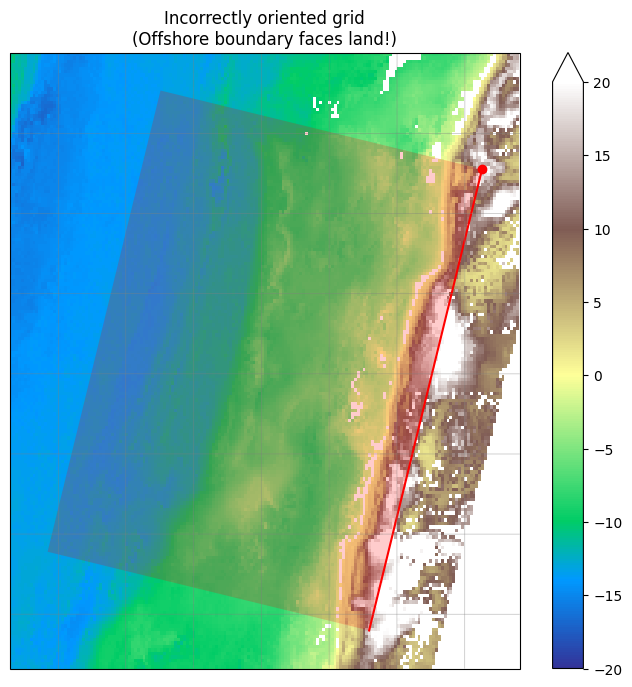

In [7]:
# Define origin at the NE corner (wrong!) with flipped rotation
grid_bad = RegularGrid(
    ori=GeoPoint(x=grid.x[-1, -1], y=grid.y[-1, -1], crs=28350),
    alfa=347 - 180,  # Flipped rotation
    dx=10, dy=15, nx=230, ny=220,
    crs="28350",
)

fig, ax = plt.subplots(subplot_kw={"projection": grid.projection}, figsize=(8.5, 8))
bathy.plot(ax=ax, transform=ccrs.PlateCarree(), cmap="terrain", vmin=-20, vmax=20)
grid_bad.plot(ax=ax, buffer=250, grid_kwargs=dict(facecolor="r", alpha=0.2))
ax.set_title("Incorrectly oriented grid\n(Offshore boundary faces land!)")

---
## 3. Interpolating Bathymetry

The `XBeachBathy` class handles interpolation from the source data onto the
XBeach grid. It requires:
- A **source** object pointing to the bathymetry data
- An **interpolator** specifying the interpolation method
- Optional **extension** for offshore boundary extension

### Basic Interpolation (No Extension)

In [8]:
# Define the data source
source = SourceGeotiff(filename=DATADIR / "bathy.tif")

# Define the interpolation method
interpolator = RegularGridInterpolator(
    kwargs=dict(
        method="linear",    # Interpolation method
        fill_value=None,    # Extrapolate at boundaries
    ),
)

# Create the bathymetry data object
data = XBeachBathy(
    source=source,
    posdwn=False,           # Negative = deeper (elevation convention)
    interpolator=interpolator,
)

In [9]:
# Generate the XBeach files
workspace = Path("./examples")
workspace.mkdir(exist_ok=True)

xfile, yfile, datafile, grid_out = data.get(destdir=workspace, grid=grid)

print("Generated files:")
for f in sorted(workspace.glob("*.txt")):
    print(f"  {f.name}")

Generated files:
  bathy.txt
  xdata.txt
  ydata.txt


### Reading and Visualising the Result

The `xbeach` accessor provides methods to read and plot XBeach bathymetry files:

In [10]:
# Read the interpolated bathymetry
dset = xr.Dataset.xbeach.from_xbeach(datafile, grid_out)
dset

<xarray.Dataset> Size: 1MB
Dimensions:      (y: 220, x: 230)
Coordinates:
    xc           (y, x) float64 405kB 3.681e+05 3.682e+05 ... 3.711e+05
    yc           (y, x) float64 405kB 6.388e+06 6.388e+06 ... 6.39e+06 6.39e+06
    spatial_ref  int64 8B 0
Dimensions without coordinates: y, x
Data variables:
    dep          (y, x) float64 405kB -13.1 -13.08 -13.08 ... 14.63 14.45 14.53

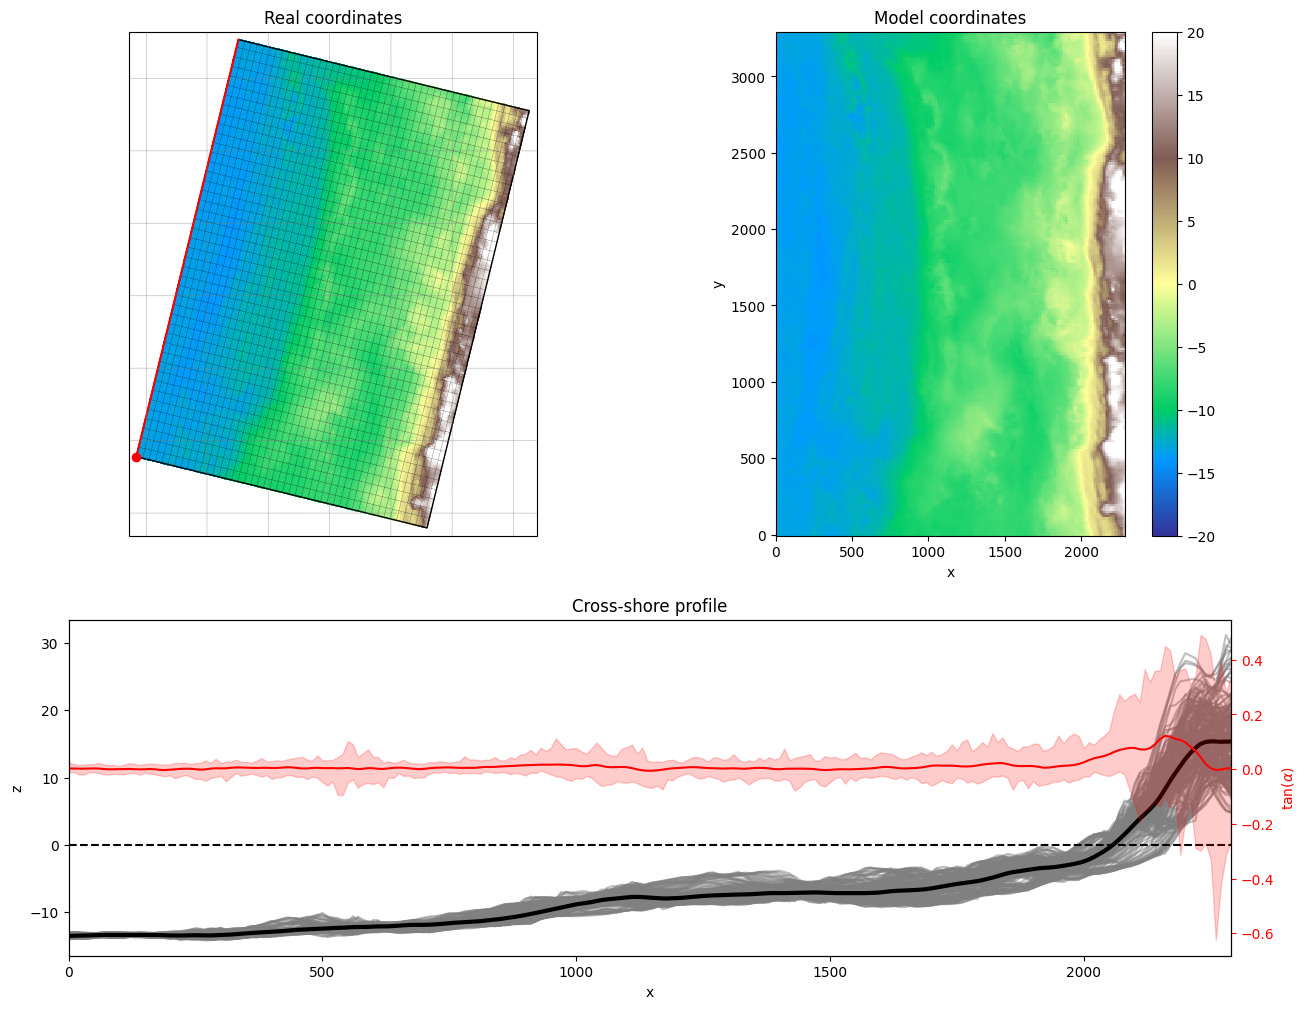

In [11]:
# Plot the model bathymetry
dset.xbeach.plot_model_bathy(grid_out, posdwn=False)

---
## 4. Offshore Extension

Often the source bathymetry doesn't extend far enough offshore for the wave
boundary with homogeneous depths. The `SeawardExtensionLinear` class extends the domain with a
linear slope to a specified depth.

In [12]:
# Define offshore extension
extension = SeawardExtensionLinear(
    depth=25,    # Target depth at offshore boundary (m)
    slope=0.1,   # Slope of the extension (rise/run)
)

# Create bathymetry with extension
data_extended = XBeachBathy(
    source=source,
    posdwn=False,
    interpolator=interpolator,
    extension=extension,
)

# Generate files
xfile2, yfile2, datafile2, grid2 = data_extended.get(destdir=workspace, grid=grid)

Text(0.5, 1.0, 'Bathymetry with Offshore Extension (slope=0.1)')

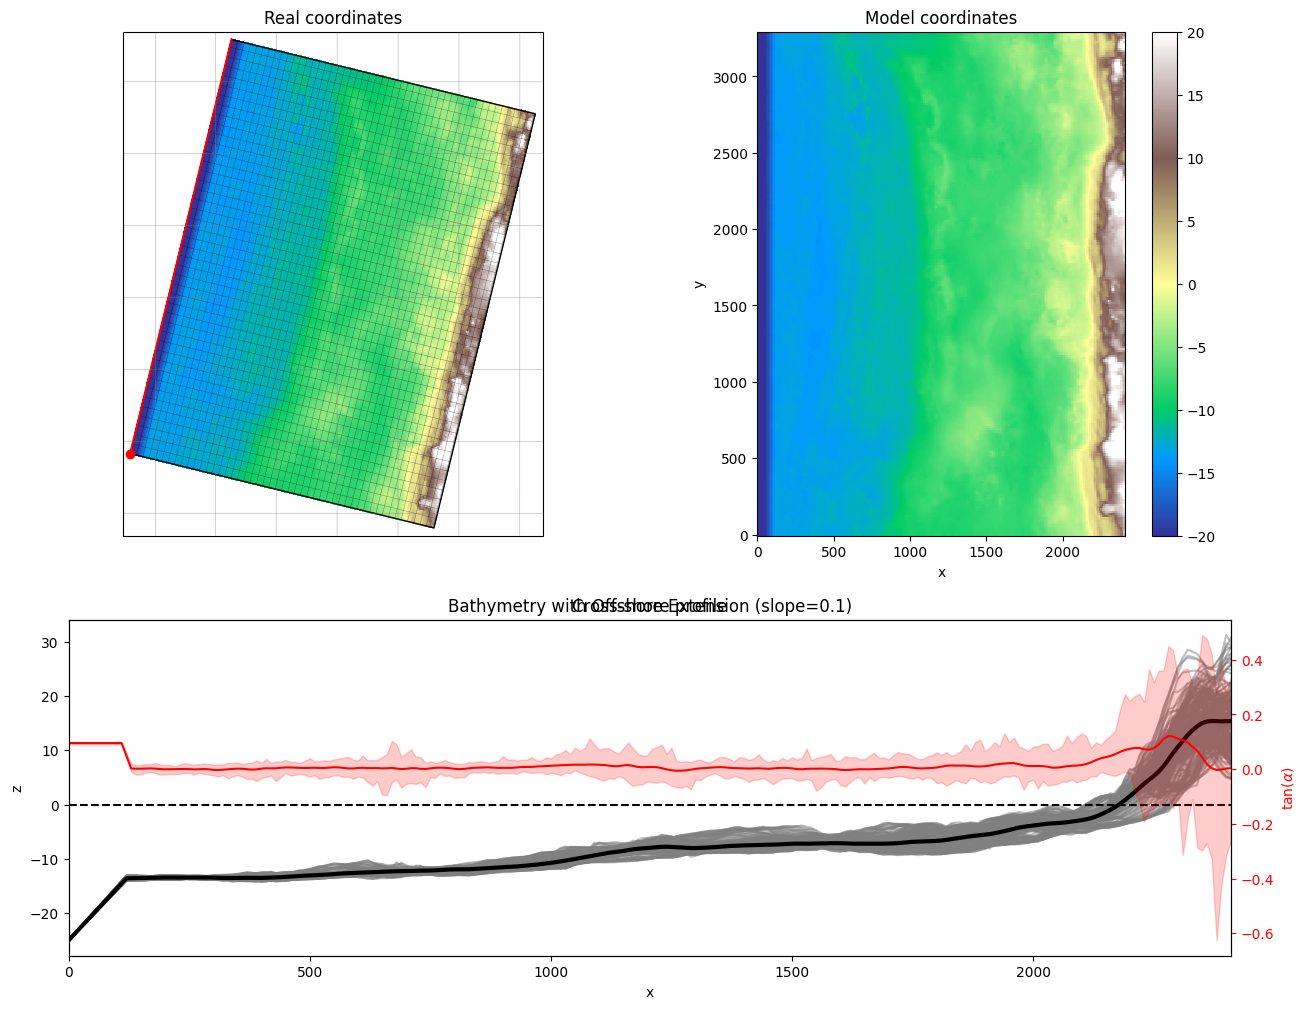

In [13]:
# Visualise the extended bathymetry
dset2 = xr.Dataset.xbeach.from_xbeach(datafile2, grid2)
dset2.xbeach.plot_model_bathy(grid2, posdwn=False)
plt.title("Bathymetry with Offshore Extension (slope=0.1)")

In [14]:
# Compare grid dimensions
print(f"Original grid:  {grid_out.shape}")
print(f"Extended grid:  {grid2.shape}")
print(f"Extension added {grid2.nx - grid_out.nx} cells offshore")

Original grid:  (220, 230)
Extended grid:  (220, 242)
Extension added 12 cells offshore


### Effect of Slope on Extension Length

A gentler slope results in a longer extension to reach the target depth:

Text(0.5, 1.0, 'Bathymetry with Gentle Slope Extension (slope=0.02)')

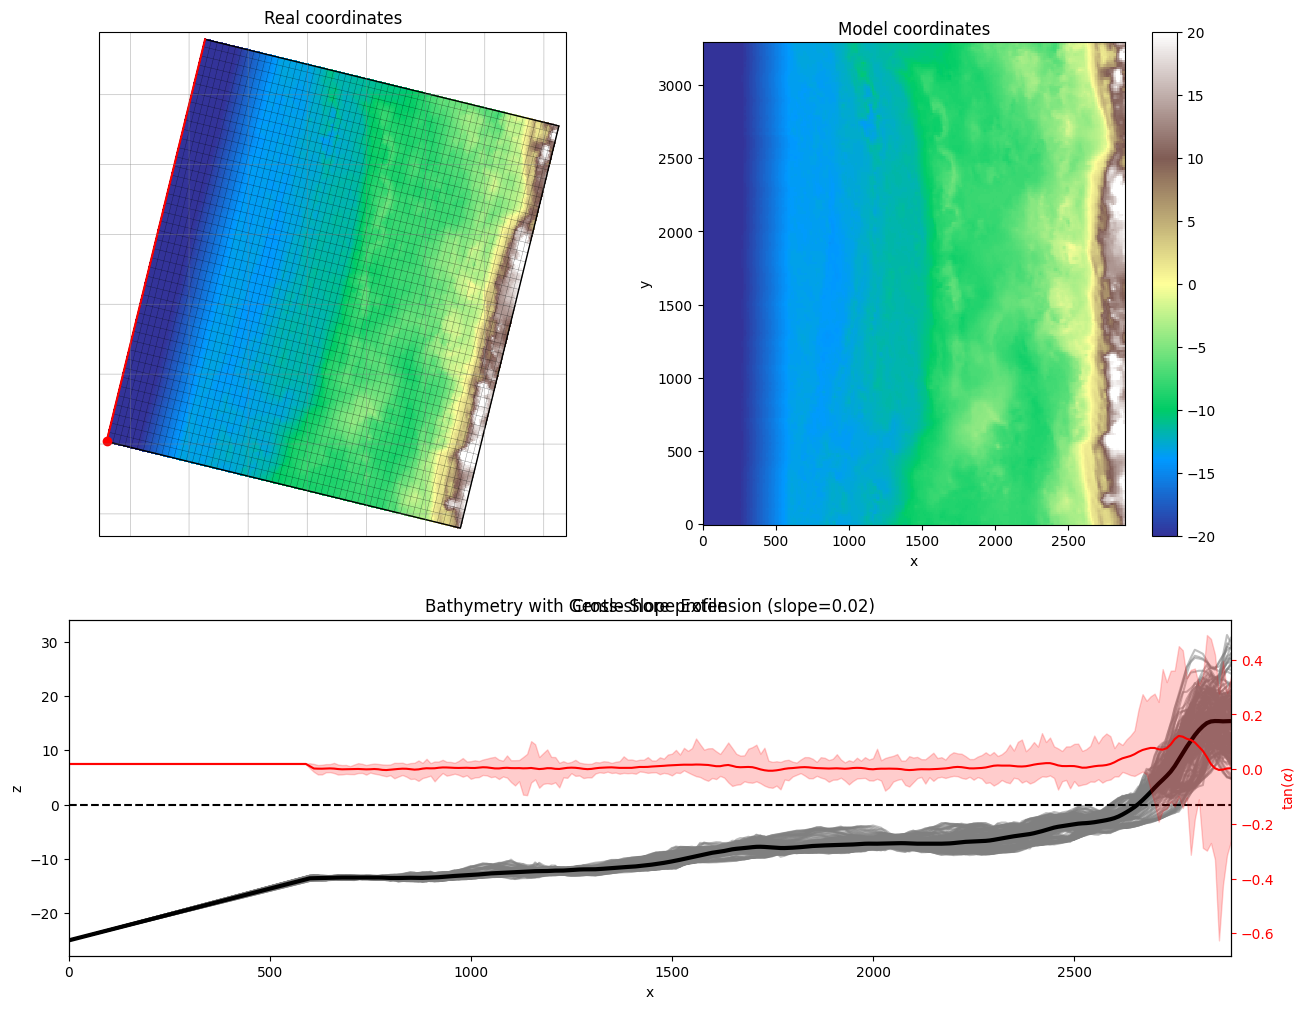

In [15]:
# Gentler slope = longer extension
extension_gentle = SeawardExtensionLinear(depth=25, slope=0.02)

data_gentle = XBeachBathy(
    source=source,
    posdwn=False,
    interpolator=interpolator,
    extension=extension_gentle,
)

xfile3, yfile3, datafile3, grid3 = data_gentle.get(destdir=workspace, grid=grid)

dset3 = xr.Dataset.xbeach.from_xbeach(datafile3, grid3)
dset3.xbeach.plot_model_bathy(grid3, posdwn=False)
plt.title("Bathymetry with Gentle Slope Extension (slope=0.02)")

In [16]:
print(f"Steep slope (0.1):   {grid2.nx - grid_out.nx} cells added")
print(f"Gentle slope (0.02): {grid3.nx - grid_out.nx} cells added")

Steep slope (0.1):   12 cells added
Gentle slope (0.02): 60 cells added


---
## 5. Lateral Extension

The domain can also be extended laterally (left and right) to provide buffer
zones for boundary conditions. This copies the edge profiles outward.

Text(0.5, 1.0, 'Bathymetry with Offshore + Lateral Extension')

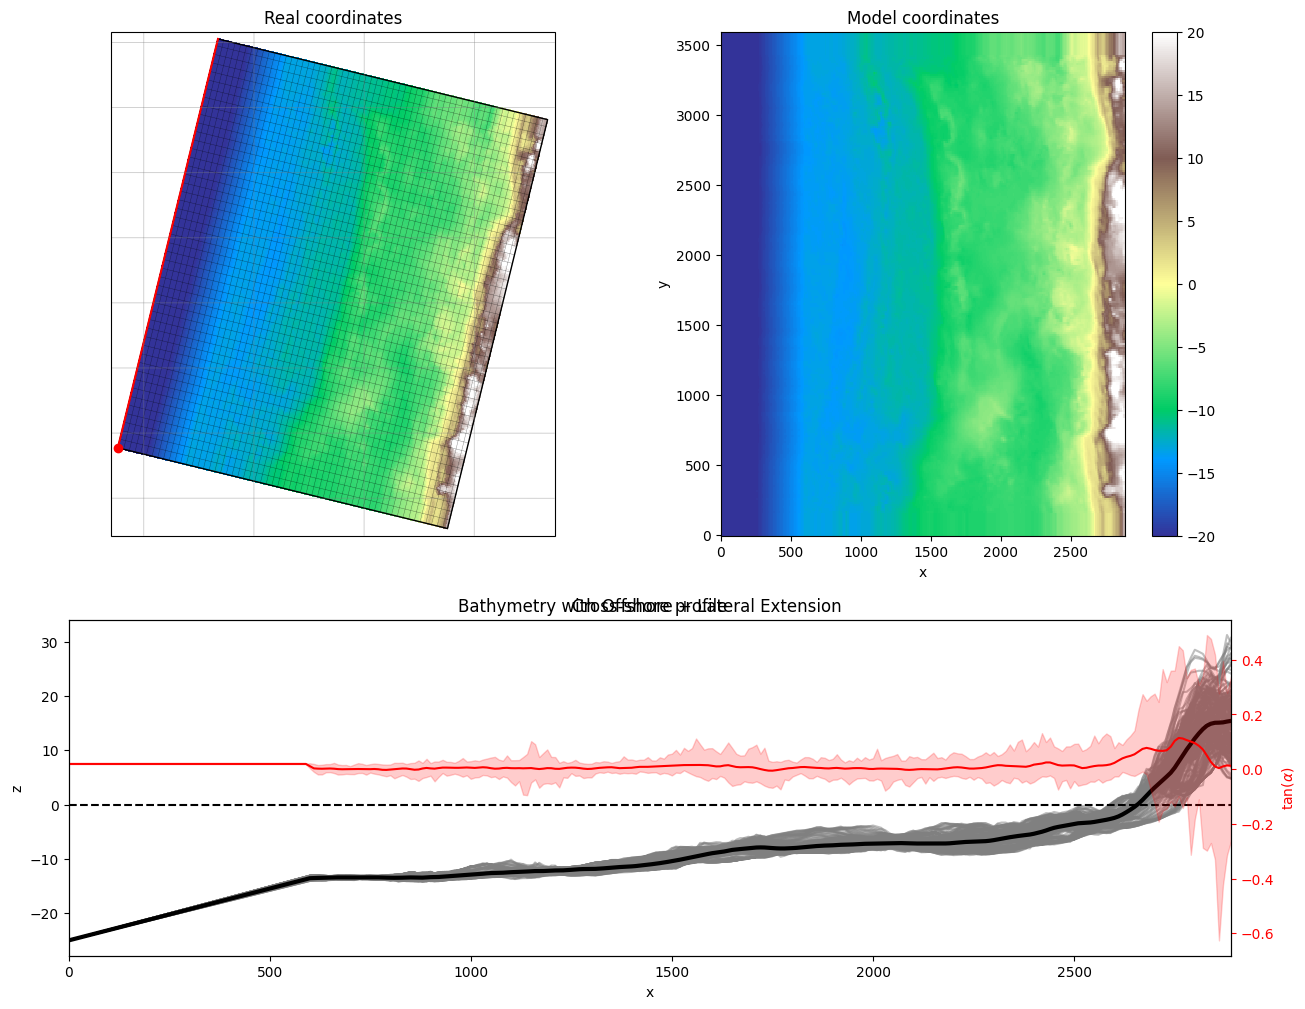

In [17]:
# Extend offshore AND laterally
data_full = XBeachBathy(
    source=source,
    posdwn=False,
    interpolator=interpolator,
    extension=SeawardExtensionLinear(depth=25, slope=0.02),
    left=10,    # Extend left boundary by 10 cells
    right=10,   # Extend right boundary by 10 cells
)

xfile4, yfile4, datafile4, grid4 = data_full.get(destdir=workspace, grid=grid)

dset4 = xr.Dataset.xbeach.from_xbeach(datafile4, grid4)
dset4.xbeach.plot_model_bathy(grid4, posdwn=False)
plt.title("Bathymetry with Offshore + Lateral Extension")

In [18]:
# Compare dimensions
print(f"No extension:        {grid_out.shape}")
print(f"Offshore only:       {grid3.shape}")
print(f"Offshore + lateral:  {grid4.shape}")

No extension:        (220, 230)
Offshore only:       (220, 290)
Offshore + lateral:  (240, 290)


---
## 6. Summary

### Key Classes

| Class | Purpose |
|-------|---------|
| `SourceGeotiff` | Load bathymetry from GeoTIFF files |
| `RegularGridInterpolator` | Configure interpolation method |
| `XBeachBathy` | Interpolate and generate XBeach bathymetry files |
| `SeawardExtensionLinear` | Extend domain offshore with linear slope |

### Key Parameters

| Parameter | Description |
|-----------|-------------|
| `source` | Data source object |
| `interpolator` | Interpolation configuration |
| `posdwn` | Depth convention (True = positive down) |
| `extension` | Offshore extension configuration |
| `left`, `right` | Lateral extension (number of cells) |

### Workflow

```python
# 1. Define source and interpolator
source = SourceGeotiff(filename="bathy.tif")
interpolator = RegularGridInterpolator(kwargs=dict(method="linear"))

# 2. Create bathymetry object with optional extensions
bathy = XBeachBathy(
    source=source,
    interpolator=interpolator,
    extension=SeawardExtensionLinear(depth=25, slope=0.05),
    left=10, right=10,
)

# 3. Generate files
xfile, yfile, datafile, grid = bathy.get(destdir=destdir, grid=grid)
```

### Next Steps

- See the **Source** tutorial for other data source types
- See the **Wave Boundary** tutorial for setting up wave forcing